
# Customer Satisfaction Prediction.

## Step 1: Import Libraries

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


## Step 2: Load Dataset

In [13]:

df = pd.read_csv('customer_support_tickets.csv')
df.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

## Step 3: Data Preprocessing

In [15]:
df = df.dropna(subset=['Customer Satisfaction Rating'])

df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], errors='coerce')

df['Purchase_Year'] = df['Date of Purchase'].dt.year
df['Purchase_Month'] = df['Date of Purchase'].dt.month
df['Purchase_Day'] = df['Date of Purchase'].dt.day

df = df.drop(['Ticket ID','Customer Name','Customer Email',
              'Ticket Description','Resolution','Date of Purchase'], axis=1)

df.head()


,Customer Age,Customer Gender,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Purchase_Year,Purchase_Month,Purchase_Day
2,48,Other,Dell XPS,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,2020,7,14
3,27,Female,Microsoft Office,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,2020,11,13
4,67,Female,Autodesk AutoCAD,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,2020,2,4
10,48,Male,Nintendo Switch,Cancellation request,Data loss,Closed,High,Phone,2023-06-01 17:46:49,2023-05-31 23:51:49,1.0,2021,1,19
11,51,Male,Microsoft Xbox Controller,Product inquiry,Software bug,Closed,High,Chat,2023-06-01 12:05:51,2023-06-01 09:27:51,1.0,2021,10,24


## Step 4: Encoding Categorical Variables

In [16]:

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()


,Customer Age,Customer Gender,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Purchase_Year,Purchase_Month,Purchase_Day
2,48,2,10,4,8,0,2,3,1347,2153,3.0,2020,7,14
3,27,0,25,0,0,0,2,3,946,293,3.0,2020,11,13
4,67,0,5,0,3,0,2,1,96,2356,1.0,2020,2,4
10,48,1,30,1,3,0,1,2,2079,85,1.0,2021,1,19
11,51,1,27,2,15,0,1,0,1452,1168,1.0,2021,10,24


## Step 5: Feature Engineering

In [17]:
X = df.drop('Customer Satisfaction Rating', axis=1)
y = df['Customer Satisfaction Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


## Step 6: Feature Scaling

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Step 7: Model Building

In [19]:

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## Step 8: Model Evaluation

In [20]:

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.18772563176895307

Classification Report:

              precision    recall  f1-score   support

         1.0       0.16      0.15      0.15       168
         2.0       0.20      0.21      0.20       174
         3.0       0.22      0.22      0.22       175
         4.0       0.19      0.19      0.19       162
         5.0       0.16      0.17      0.17       152

    accuracy                           0.19       831
   macro avg       0.19      0.19      0.19       831
weighted avg       0.19      0.19      0.19       831


Confusion Matrix:

[[25 35 42 32 34]
 [39 36 36 29 34]
 [35 31 39 37 33]
 [38 37 23 30 34]
 [21 41 38 26 26]]


## Step 9: Feature Importance Analysis

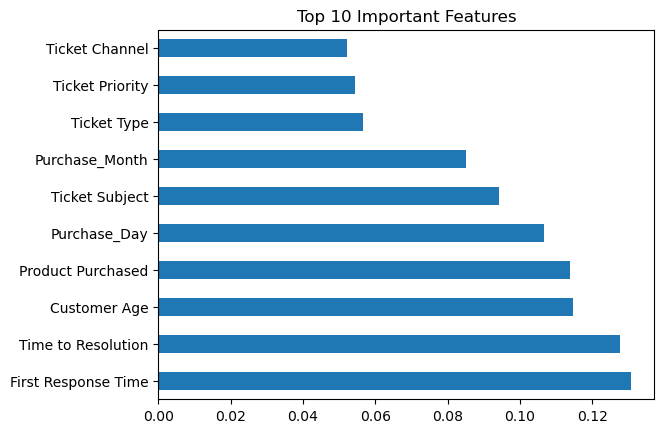

In [21]:

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()


## Step 10: Exploratory Data Analysis (EDA)

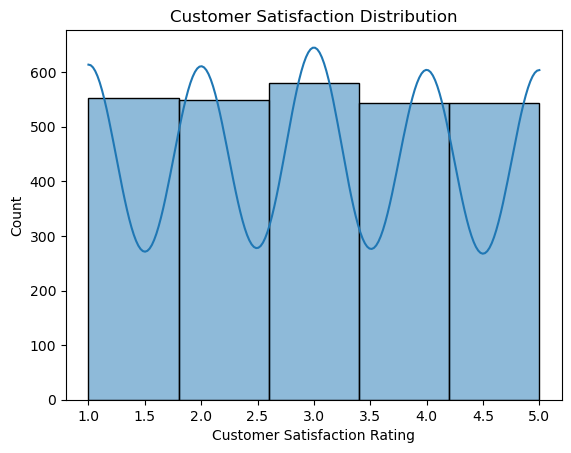

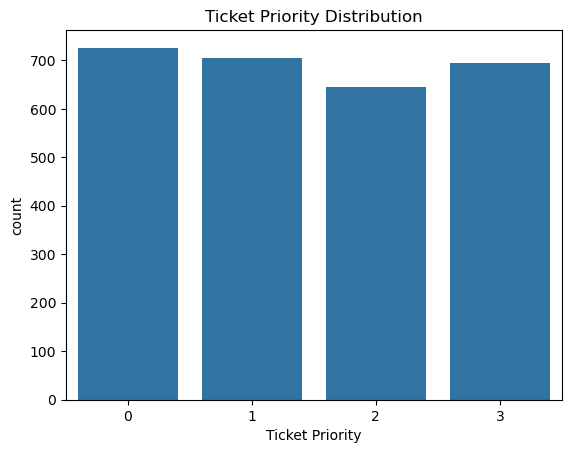

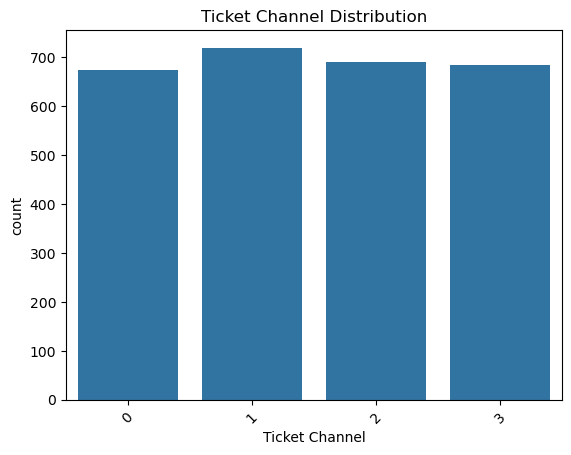

In [22]:

sns.histplot(df['Customer Satisfaction Rating'], bins=5, kde=True)
plt.title('Customer Satisfaction Distribution')
plt.show()

sns.countplot(x='Ticket Priority', data=df)
plt.title('Ticket Priority Distribution')
plt.show()

sns.countplot(x='Ticket Channel', data=df)
plt.xticks(rotation=45)
plt.title('Ticket Channel Distribution')
plt.show()
